In [98]:
import gamry_parser
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
from pathlib import Path
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import make_splrep
import math
from scipy.signal import savgol_filter

main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\EIS_data")
file_list = list(main_dir.rglob('*_168H.DTA'))

all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    data = parser.curves[0]
    eis_data = {
        'name':str(filename).split("\\")[-1],
        'Pt': data.index.values,
        'Zreal':data['Zreal'].values,
        'Zimag':-data['Zimag'].values,
        'Zmod':data['Zmod'].values,
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values
    }

    eis_data_clean = {
        'name':str(filename).split("\\")[-1],
        'Pt': data.index.values,
        'Zreal':data['Zreal'].values,
        'Zimag':data['Zimag'].values,
        'Zmod':data['Zmod'].values,
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values
    }
    

    gaps = np.where(np.diff(eis_data['Pt']) != 1)[0]
  
    if len(gaps) > 0:
        for idx in reversed(gaps):
            num_missing = int(np.diff(eis_data['Pt'])[idx] - 1)
        
            # Define start and end anchors from the current state of clean data
            f_start, f_end = eis_data_clean['Freq'][idx], eis_data_clean['Freq'][idx+1]
            re_start, re_end = eis_data_clean['Zreal'][idx], eis_data_clean['Zreal'][idx+1]
            im_start, im_end = eis_data_clean['Zimag'][idx], eis_data_clean['Zimag'][idx+1]
            print(im_start,im_end)
            pt_start = eis_data_clean['Pt'][idx]
    
            # --- Generate the "Bridge" ---
            # Frequency: Geometric space (Logarithmic)
            f_bridge = np.geomspace(f_start, f_end, num_missing + 2)[1:-1]
            
            # Components: Linear space
            re_bridge = np.linspace(re_start, re_end, num_missing + 2)[1:-1]
            im_bridge = np.linspace(im_start, im_end, num_missing + 2)[1:-1]
            
            # Point numbers: Integers
            pt_bridge = np.arange(pt_start + 1, pt_start + 1 + num_missing)
    
            # --- Calculate Derived Values for the Bridge ---
            mod_bridge = np.sqrt(re_bridge**2 + im_bridge**2)
            # Degrees for Phase
            phz_bridge = np.degrees(np.arctan2(im_bridge, re_bridge))
    
            # --- Insert into eis_data_clean ---
            eis_data_clean['Freq'] = np.insert(eis_data_clean['Freq'], idx + 1, f_bridge)
            eis_data_clean['Zreal'] = np.insert(eis_data_clean['Zreal'], idx + 1, re_bridge)
            eis_data_clean['Zimag'] = np.insert(eis_data_clean['Zimag'], idx + 1, im_bridge)
            eis_data_clean['Zmod'] = np.insert(eis_data_clean['Zmod'], idx + 1, mod_bridge)
            eis_data_clean['Zphz'] = np.insert(eis_data_clean['Zphz'], idx + 1, phz_bridge)
            eis_data_clean['Pt'] = np.insert(eis_data_clean['Pt'], idx + 1, pt_bridge)
    
    print(f"Cleaned data created. Total points: {len(eis_data_clean['Pt'])}")
            
    eis_data_savgol = {
        'name':str(filename).split("\\")[-1],
        'Zreal':savgol_filter(np.flip(eis_data_clean['Zreal']),window_length=11, polyorder=3),
        'Zimag':-savgol_filter(np.flip(eis_data_clean['Zimag']),window_length=11, polyorder=3),
        'Zmod':savgol_filter(np.flip(eis_data_clean['Zmod']),window_length=11, polyorder=3),
        'Zphz':savgol_filter(np.flip(eis_data_clean['Zphz']),window_length=11, polyorder=3),
        'Freq':np.flip(eis_data_clean['Freq'])
    }
    
    all_datasets.append({"eis_data":eis_data,"eis_data_clean":eis_data_clean, "eis_data_savgol":eis_data_savgol})
    print(eis_data['name'])


Cleaned data created. Total points: 71
Cauvel_2_8HQ_168H.DTA
Cleaned data created. Total points: 71
Cauvel_3_BTA_168H.DTA
Cleaned data created. Total points: 71
Cauvel_1_Lcystine_168H.DTA
Cleaned data created. Total points: 71
Cauvel_1_MBT_168H.DTA
Cleaned data created. Total points: 71
Cauvel_3_Mo_168H.DTA
Cleaned data created. Total points: 71
Cauvel_4_NaCl_168H.DTA
Cleaned data created. Total points: 71
Cauvel_2_NaVO3_168H.DTA
Cleaned data created. Total points: 71
Cauvel_4_NaVO3_168H.DTA


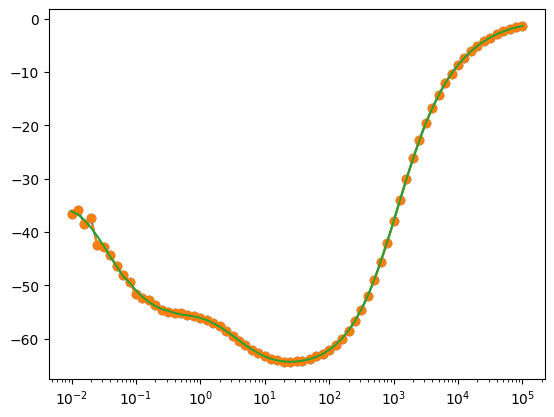

In [99]:
plt.semilogx(all_datasets[6]['eis_data']['Freq'],all_datasets[6]['eis_data']['Zphz'],'o-')
plt.semilogx(all_datasets[6]['eis_data_clean']['Freq'],all_datasets[6]['eis_data_clean']['Zphz'],'o--')
plt.semilogx(all_datasets[6]['eis_data_savgol']['Freq'],all_datasets[6]['eis_data_savgol']['Zphz'])

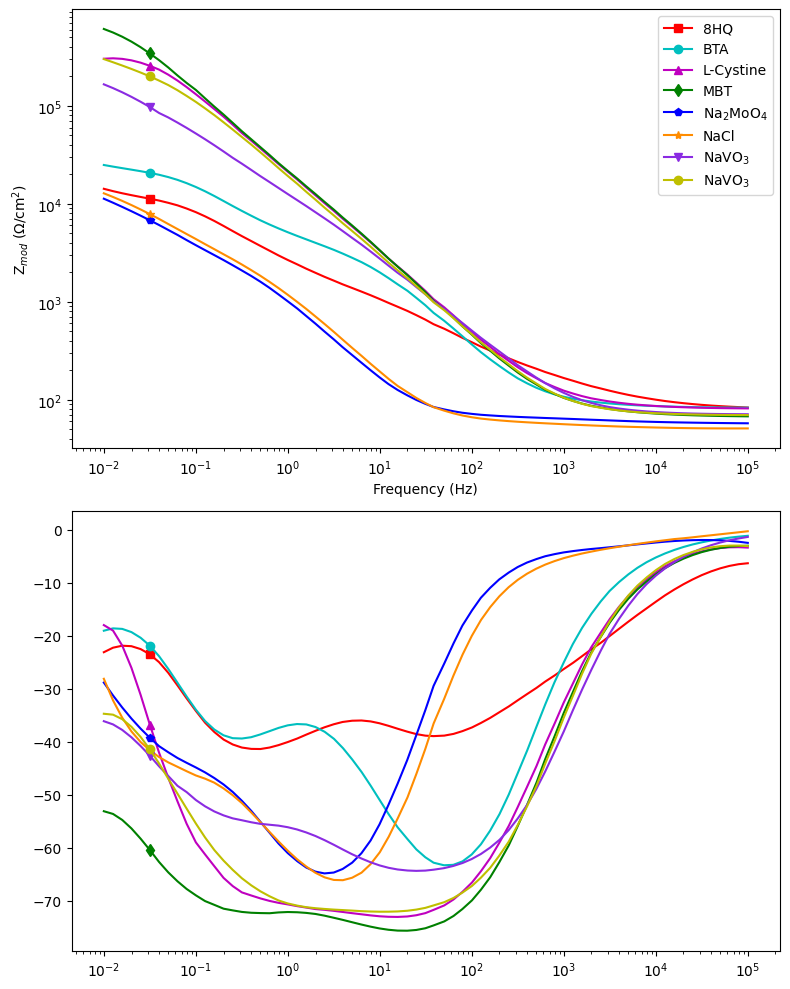

In [100]:
colors = ["r", "c", "m", "g", "b", "darkorange", "blueviolet", "y"]
markers = ['s', 'o', '^', 'd', 'p', '*', 'v', 'o']
label_formatter = {
    'NaVO3': r'NaVO$_3$',      
    'NaCl': 'NaCl',            
    '8HQ': '8HQ',              
    'BTA': 'BTA',
    'Lcystine': 'L-Cystine',   
    'MBT': 'MBT',
    'Mo': 'Na$_2$MoO$_4$'
}
fig,(ax1,ax2) = plt.subplots(2,1,figsize = (8,10))

for i, dataset in enumerate(all_datasets):
    #ax1.loglog(dataset['eis_data']['Freq'],dataset['eis_data']['Zmod'],label = dataset['eis_data_filtered']['name'])
    raw_name = dataset['eis_data_savgol']['name'].split('_')[2]
    label = label_formatter.get(raw_name)
    ax1.loglog(
        dataset['eis_data_savgol']['Freq'],
        dataset['eis_data_savgol']['Zmod'],
        label=label,
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         
        markersize=6,          
        markevery=(5,70)
    )
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel(r'Z$_{mod}$ ($\Omega$/cm$^2$)')
    ax1.legend()

for i, dataset in enumerate(all_datasets):
    #ax2.semilogx(dataset['eis_data']['Freq'],dataset['eis_data']['Zphz'],label = dataset['eis_data_filtered']['name'])
    ax2.semilogx(
        dataset['eis_data_savgol']['Freq'],
        dataset['eis_data_savgol']['Zphz'],
        label = dataset['eis_data_savgol']['name'],
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,70)
    )

plt.tight_layout()
plt.show()

[np.float64(9866.10730769231), np.float64(11277.616034965033), np.float64(13076.259181818185), np.float64(23498.609230769234), np.float64(133645.87314685318), np.float64(246290.03153846148), np.float64(288817.76069930074), np.float64(365329.6106293707)]


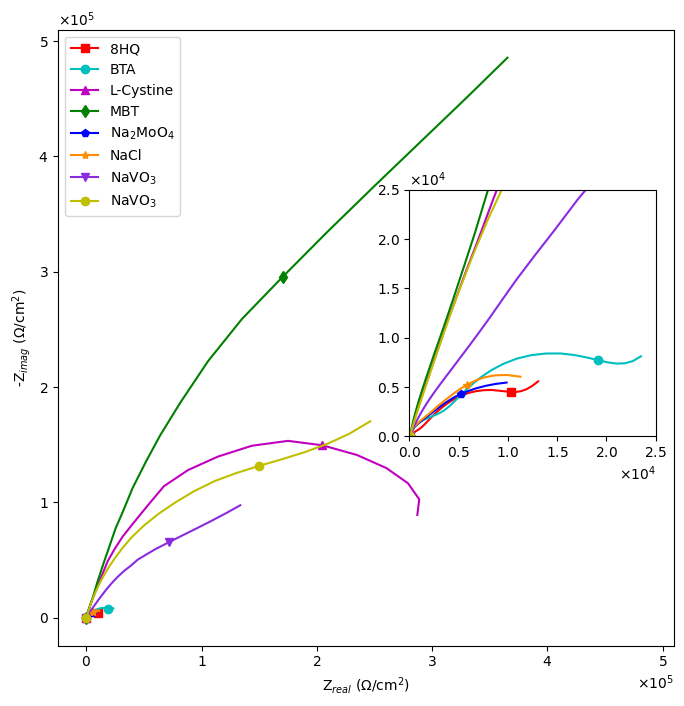

In [101]:
fig2, ax3 = plt.subplots(figsize=(8, 8))
axins = ax3.inset_axes([0.57, 0.34, 0.4, 0.4])
Max_Zreals = []
Max_Zimags = []

main_step = 100e3
inset_step = 5e3

for i, dataset in enumerate(all_datasets):
    raw_name = dataset['eis_data_savgol']['name'].split('_')[2]
    label = label_formatter.get(raw_name)
    ax3.plot(
        dataset['eis_data_savgol']['Zreal'],
        dataset['eis_data_savgol']['Zimag'],
        label = label,
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,65)
    )
    ax3.legend(loc = 'upper left')
    ax3.xaxis.set_major_locator(MultipleLocator(main_step))
    ax3.yaxis.set_major_locator(MultipleLocator(main_step))
    ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
    
    axins.plot(
        dataset['eis_data_savgol']['Zreal'],
        dataset['eis_data_savgol']['Zimag'],
        label = dataset['eis_data_savgol']['name'],
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,65)
    )
    axins.xaxis.set_major_locator(MultipleLocator(inset_step))
    axins.yaxis.set_major_locator(MultipleLocator(inset_step))
    axins.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
    
    max_Zreals = dataset['eis_data_savgol']['Zreal'].max()
    max_Zimags = dataset['eis_data_savgol']['Zimag'].max()
    Max_Zreals.append(max_Zreals)
    Max_Zimags.append(max_Zimags)


ax3.set_aspect('equal')
ax3.set_xlabel(r'Z$_{real}$ ($\Omega$/cm$^2$)')
ax3.set_ylabel(r'-Z$_{imag}$ ($\Omega$/cm$^2$)')


Max_Zreals.sort()
print(Max_Zreals)

axins.set_xlim(0, 25000)
axins.set_ylim(0, 25000)
#print(overall_min_inset,overall_max_inset)

x_min, x_max = ax3.get_xlim()
y_min, y_max = ax3.get_ylim()
overall_min = min(x_min, y_min)
overall_max = max(x_max, y_max)
ax3.set_xlim(overall_min, overall_max)
ax3.set_ylim(overall_min, overall_max)

plt.show()

